# Data 602 Finals : Fake Profile Detection by Clustering

## Objective
To identify likely fake or suspicious social media profiles using unlabeled behavioral data.

## Approach
This problem is treated as a **semi-supervised learning** and the following is the plan:
1. Perform basic EDA and feature engineering
2. Use clustering to discover natural groups
3. Use SME for some labels
4. Assign pseudo-labels to clusters
5. Train multiple models on pseudo-labeled data

## Evaluation Strategy
- Internal validation: cross-validation on pseudo-labels
- Check generalization: performance on unseen data
- Final evaluation: compare predictions with actual labels at the end

In [1]:
## Importing all required Libraries

# BASIC LIBRARIES (DATA HANDLING)
import pandas as pd
import numpy as np

# DATA VISUALIZATION (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPROCESSING
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# MACHINE LEARNING MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

# CLUSTERING
from sklearn.cluster import KMeans

# MODEL EVALUATION METRICS
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# CROSS VALIDATION
from sklearn.model_selection import cross_val_score

# HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV

In [2]:
#loading data
df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/fake_profiles_unlabeled.csv')

# Sanity checks
print(df.shape)
print(df.head())
print(df.info())

(5000, 19)
  profile_id  account_age_days  bio_length  profile_picture_quality  \
0     P00001               549         131                    0.575   
1     P00002               204          29                    0.319   
2     P00003              1021          73                    0.572   
3     P00004               998           7                    0.726   
4     P00005              1096          28                    0.825   

   posts_count  followers_count  following_count  posts_last_30_days  \
0          350             1681               60                   0   
1           30              317             1701                  33   
2          374              312              451                  11   
3          127              169              192                   5   
4          287              336              598                   8   

   external_link_count  username_digit_count  username_length  \
0                    0                     0               12   

## Data Cleaning

In [3]:
# missing values
print(df.isnull().sum())

profile_id                 0
account_age_days           0
bio_length                 0
profile_picture_quality    0
posts_count                0
followers_count            0
following_count            0
posts_last_30_days         0
external_link_count        0
username_digit_count       0
username_length            0
repeated_captions          0
recent_posts_sampled       0
avg_caption_length         0
night_posts                0
likes_last_20_posts        0
comments_last_20_posts     0
dm_sent_last_7_days        0
dm_replies_last_7_days     0
dtype: int64


In [4]:
print(df.duplicated().any())

False


We see that there are no missing values or duplicate rows in the data, hence no data cleaning steps are necessary.

## EDA

In [5]:
# Separate ID
id_col = "profile_id"
feature_cols = [c for c in df.columns if c != id_col]

### Feature distributions (histograms)

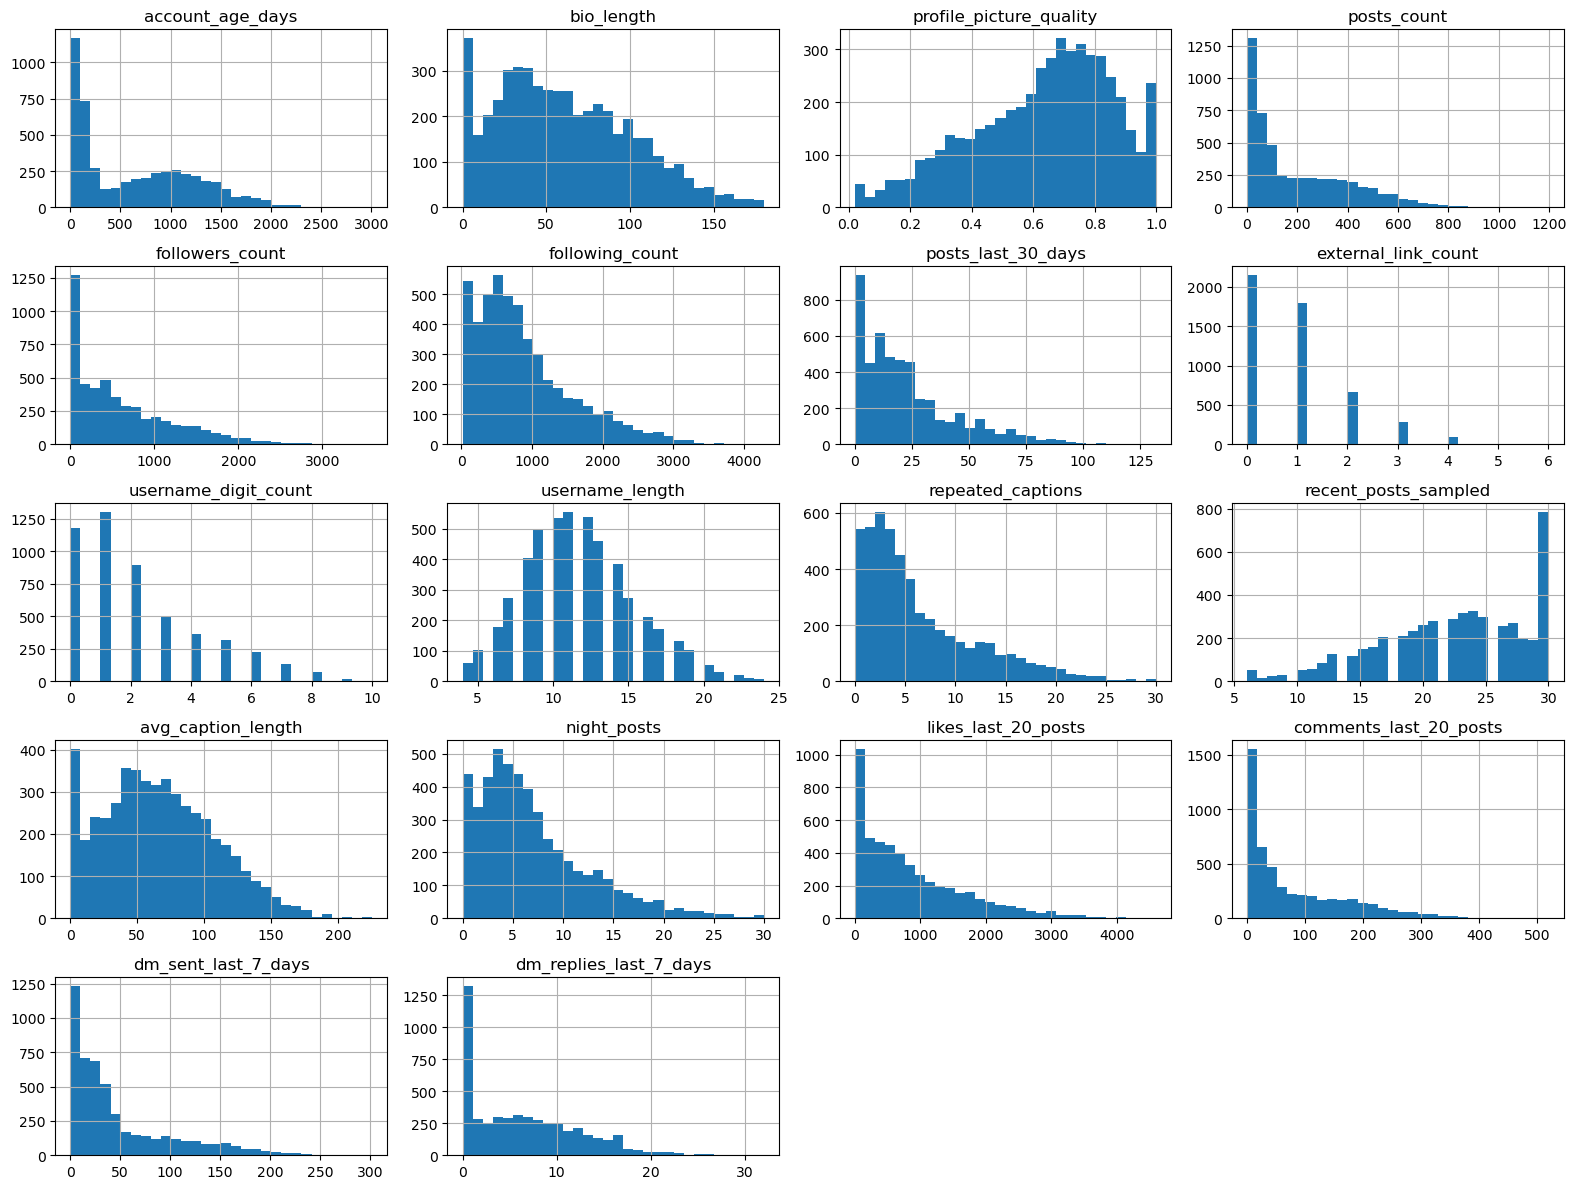

In [6]:
# Histograms
df[feature_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

**Interpretation of distributions:**


- **Strong right skew for count-based variables:** `posts_count`, `followers_count`, `following_count`, `posts_last_30_days`, `likes_last_20_posts`, `comments_last_20_posts`, `dm_sent_last_7_days`, and `repeated_captions` have a huge concentration near zero, followed by a long tail. We observe a lot of low-activity users, but there are some outliers who have extremely high activity – just what we would expect to see when some users drastically differ from the majority
- **`account_age_days` is bimodal:** an obvious peak of very young accounts, as well as a less obvious, broad peak of accounts aged more than ~1000 days. The first peak is among the strongest signs of fake accounts.
- **`profile_picture_quality`** tends to take larger values (median ≈ 0.67), yet there is still **an important fraction of bad pictures** – poorly edited or even automatically generated accounts.
- **Modeling consequence:** the strong skewness makes our distance-based algorithms perform poorly without proper data scaling and converting raw counts into ratios and rates; both are done later in the project.

### Correlation heatmap

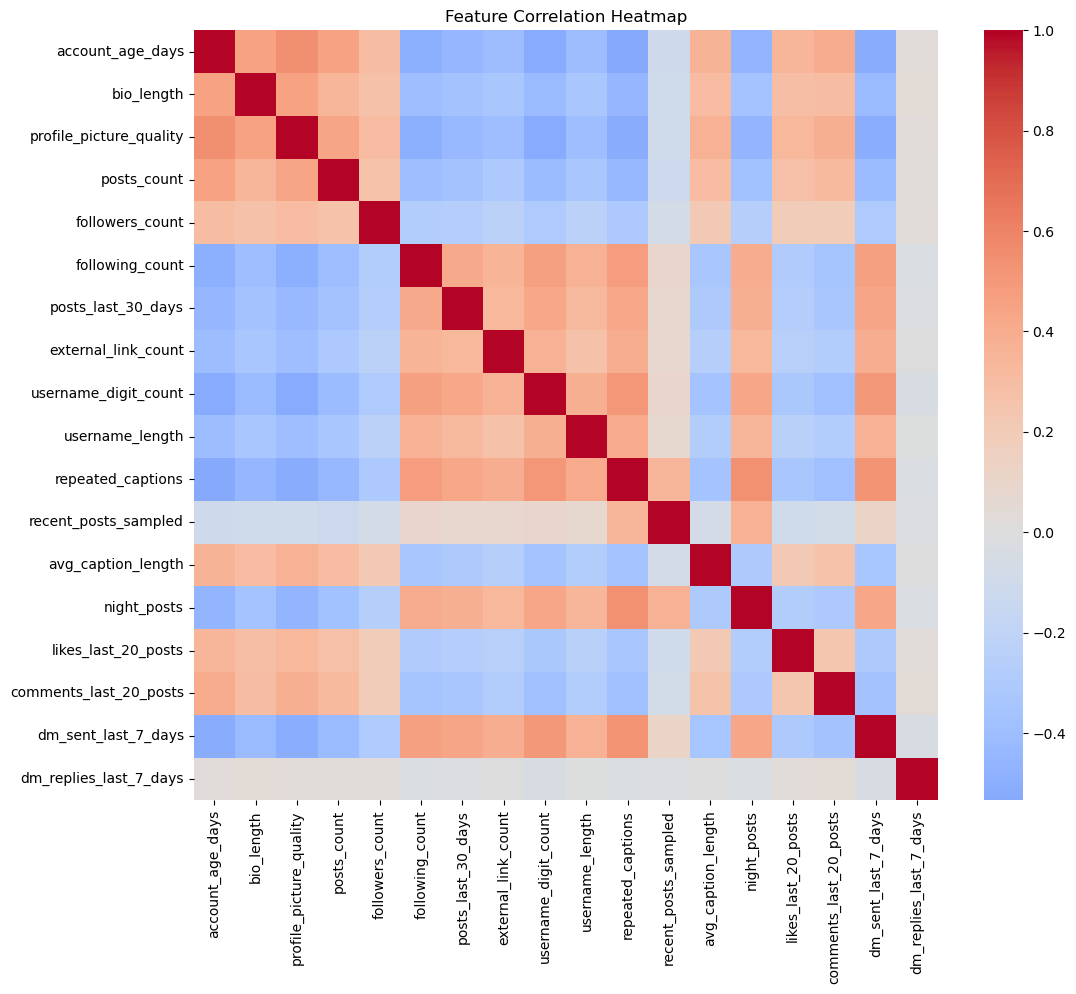

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

**Interpretation of the correlation heatmap:**


There appears to be two clear groups of features:
- **Group A ("established account" indicators):** `account_age_days`, `bio_length`, `profile_picture_quality`, `posts_count`, `followers_count`, `likes_last_20_posts`, `comments_last_20_posts`. This group of features is positively correlated with each other (mostly the upper left corner of reddish squares).
- **Group B ("high activity / low effort" indicators):** `following_count`, `posts_last_30_days`, `external_link_count`, `username_digit_count`, `repeated_captions`, `night_posts`, `dm_sent_last_7_days`. This group is positively correlated within itself (the middle reddish square cluster).
- **Group A is negatively correlated with Group B** (blue cells along the off-diagonal). Features which appear to indicate an "established account" correlate negatively with those which suggest suspicious behavior, and vice versa. It’s exactly this distinction which allows unsupervised clustering to make sense, since there seems to be separation in the data naturally.

### Descriptive statistics summary

Beyond the histograms, the numeric summary below adds skewness, IQR, and the mean-to-median ratio so the skew is quantified rather than just visual.

In [8]:
summary = df[feature_cols].describe().T
summary["skew"] = df[feature_cols].skew()
summary["iqr"] = summary["75%"] - summary["25%"]
summary["mean_to_median_ratio"] = summary["mean"] / summary["50%"].replace(0, np.nan)
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,iqr,mean_to_median_ratio
account_age_days,5000.0,650.40,584.86,1.00,109.00,540.00,1107.00,3005.0,0.63,998.00,1.20
bio_length,5000.0,60.65,40.21,0.00,29.00,55.00,89.00,180.0,0.49,60.00,1.10
profile_picture_quality,5000.0,0.63,0.23,0.02,0.48,0.67,0.80,1.0,-0.52,0.32,0.95
posts_count,5000.0,198.46,197.32,0.00,36.00,118.00,332.00,1197.0,1.00,296.00,1.68
followers_count,5000.0,618.08,607.22,0.00,113.00,447.00,965.00,3590.0,1.15,852.00,1.38
following_count,5000.0,889.87,690.33,15.00,391.75,725.00,1227.00,4282.0,1.09,835.25,1.23
posts_last_30_days,5000.0,23.14,21.45,0.00,7.00,18.00,32.00,132.0,1.31,25.00,1.29
external_link_count,5000.0,0.88,0.98,0.00,0.00,1.00,1.00,6.0,1.19,1.00,0.88
username_digit_count,5000.0,2.14,2.08,0.00,1.00,2.00,3.00,10.0,1.09,2.00,1.07
username_length,5000.0,11.60,3.66,4.00,9.00,11.00,14.00,24.0,0.43,5.00,1.05


**Interpretation:**

- **Skew > 1** suggests that the attribute is heavily skewed to the right. `external_link_count`, `posts_last_30_days`, `dm_sent_last_7_days`, `repeated_captions`, and `comments_last_20_posts` all belong in this category.
- The **mean/median** ratio is greater than 1 in these above cases, indicating the mean is distorted by just a few outliers and not representative of the average member.
- For `account_age_days`, the **IQR is very large**, around 1000 days. This means that there is high variability, and the population is truly split between very new and well-established accounts.

### Boxplots: outlier visibility

Histograms show shape; boxplots show outliers explicitly. Because the raw scales differ by orders of magnitude, we standardize first (mean 0, sd 1) so all features fit on the same axis.

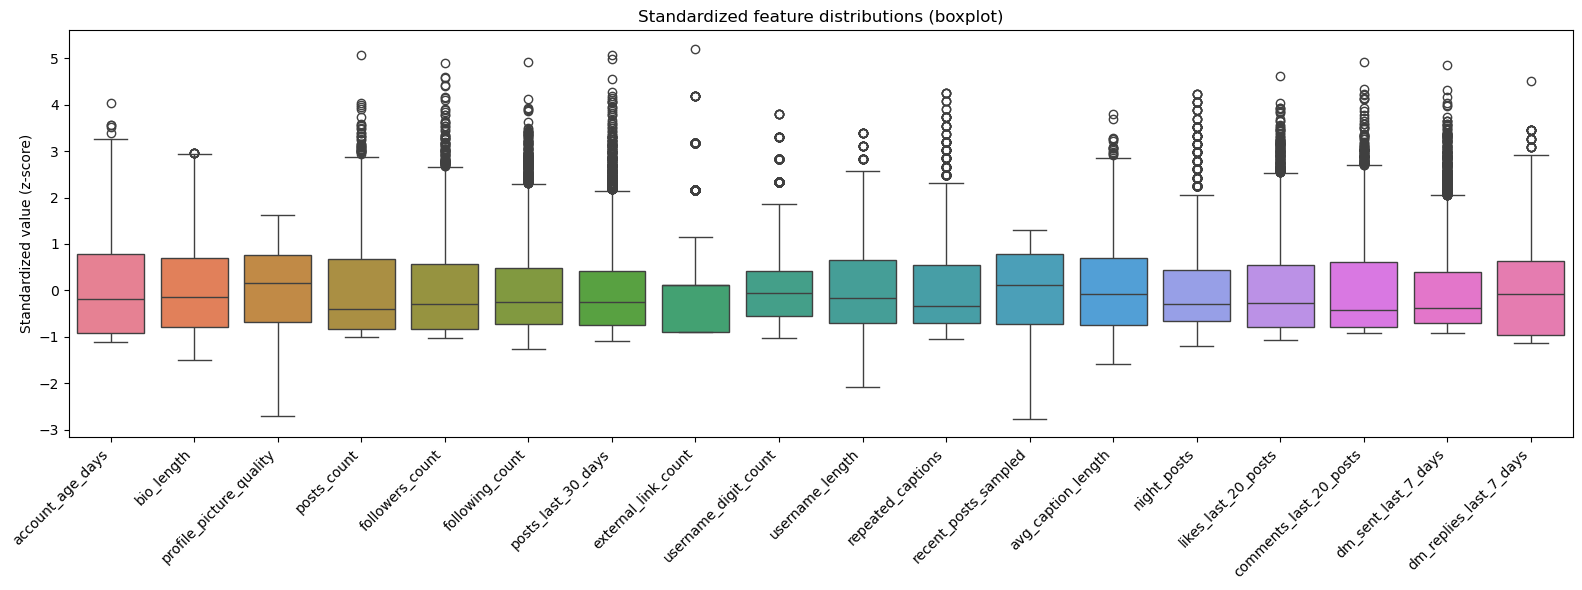

In [9]:
scaler_eda = StandardScaler()
scaled_eda = pd.DataFrame(
    scaler_eda.fit_transform(df[feature_cols]),
    columns=feature_cols,
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=scaled_eda, orient="v")
plt.xticks(rotation=45, ha="right")
plt.title("Standardized feature distributions (boxplot)")
plt.ylabel("Standardized value (z-score)")
plt.tight_layout()
plt.show()

**Interpretation:**

The following features have many values more than +3 standard deviations on the right tail side, especially `posts_count`, `followers_count`, `following_count`, `posts_last_30_days`, `repeated_captions`, `comments_last_20_posts`, and `dm_sent_last_7_days`. The extreme values are precisely the ones we should be looking for in forming clusters of suspicious accounts, so it is intentional that we **not remove** them because they represent the signal, not the noise. We shall form new features from them.

### Followers vs. Following

One of the most cited fake-profile signals is an unusual ratio between followers and following — fake or bot accounts often follow many but are followed by few. Let's view this directly.

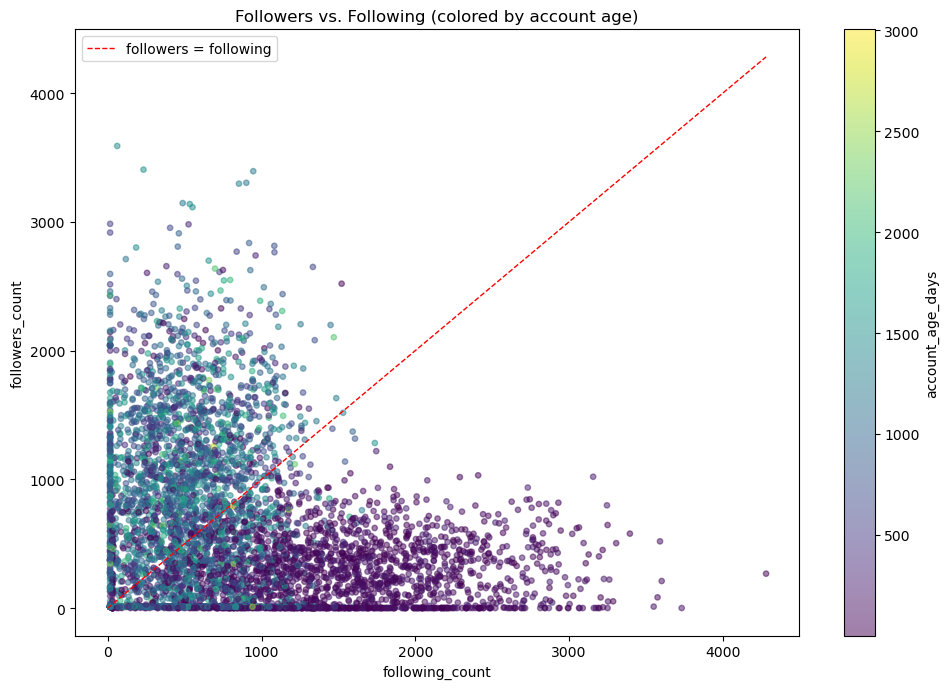

In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(
    df["following_count"],
    df["followers_count"],
    c=df["account_age_days"],
    cmap="viridis",
    alpha=0.5,
    s=15,
)
plt.colorbar(label="account_age_days")
plt.plot([0, df["following_count"].max()], [0, df["following_count"].max()],
         color="red", linestyle="--", linewidth=1, label="followers = following")
plt.xlabel("following_count")
plt.ylabel("followers_count")
plt.title("Followers vs. Following (colored by account age)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

The data points falling significantly **below the red line** (large `following_count` value and small `followers_count` value) represent the stereotypical fake profile pattern where the account follows many other accounts but receives little following in turn. When plotted against `account_age_days`, it is evident that many of these data points lying below the line are also **newly created accounts** (dark color).

### Account age vs. posting activity

The histogram showed `account_age_days` is bimodal. If young accounts behave differently (e.g., post more aggressively, follow many people), that's a strong fake-profile signal. Let's bucket accounts by age and compare posting behavior.

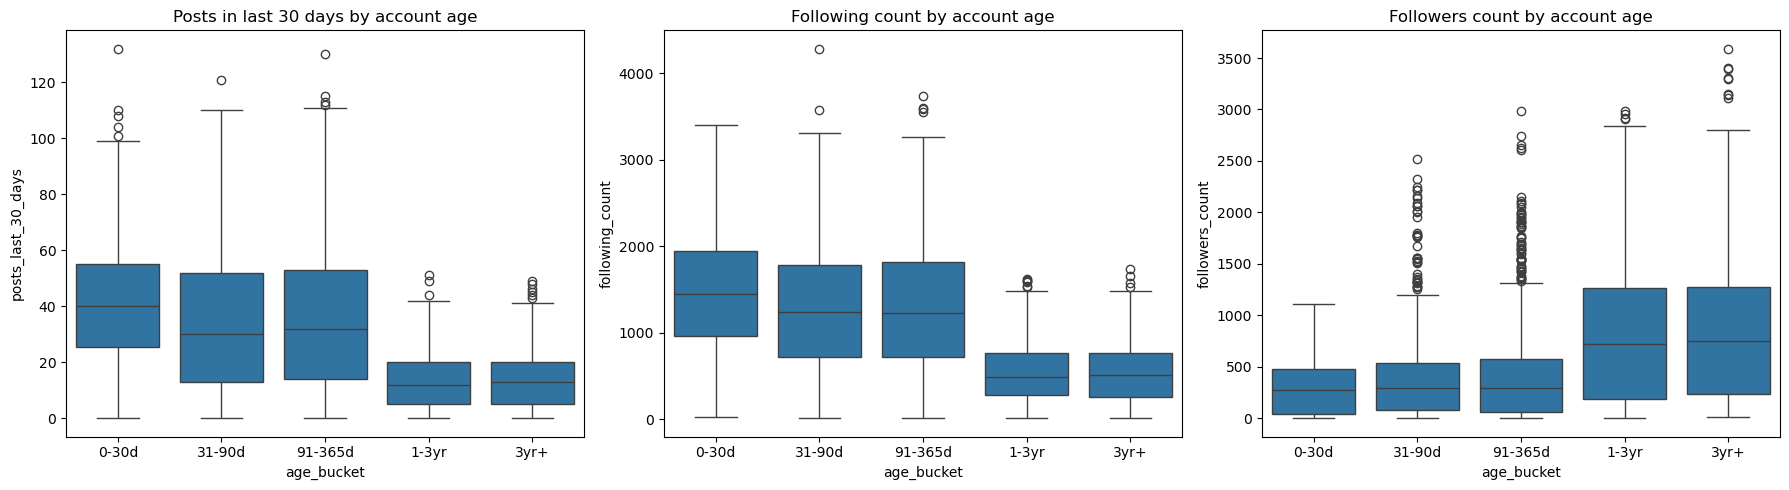

Accounts per age bucket:
age_bucket
0-30d       422
31-90d      621
91-365d    1208
1-3yr      1476
3yr+       1273
Name: count, dtype: int64


In [11]:
df_eda = df.copy()
age_bins = [0, 30, 90, 365, 1095, df["account_age_days"].max() + 1]
age_labels = ["0-30d", "31-90d", "91-365d", "1-3yr", "3yr+"]
df_eda["age_bucket"] = pd.cut(df_eda["account_age_days"], bins=age_bins, labels=age_labels, right=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_eda, x="age_bucket", y="posts_last_30_days", ax=axes[0])
axes[0].set_title("Posts in last 30 days by account age")

sns.boxplot(data=df_eda, x="age_bucket", y="following_count", ax=axes[1])
axes[1].set_title("Following count by account age")

sns.boxplot(data=df_eda, x="age_bucket", y="followers_count", ax=axes[2])
axes[2].set_title("Followers count by account age")

plt.tight_layout()
plt.show()

print("Accounts per age bucket:")
print(df_eda["age_bucket"].value_counts().sort_index())

**Interpretation:**
- The youngest bucket (0-30 days) is shows **an unusually large number of posts and following counts** compared to the followers obtained, which is a typical spam behavior.
- For older accounts (3 years+), we observe **a relatively higher number of followers with a lower number of follows**, indicating organic growth.
- The differences across buckets provide clear evidence for using account age as an important dimension in the clustering process.

### Engagement per follower

Followers can be bought; genuine engagement (likes, comments) is harder to fake. Profiles with many followers but very low engagement are suspicious — they may have inflated their follower counts artificially.

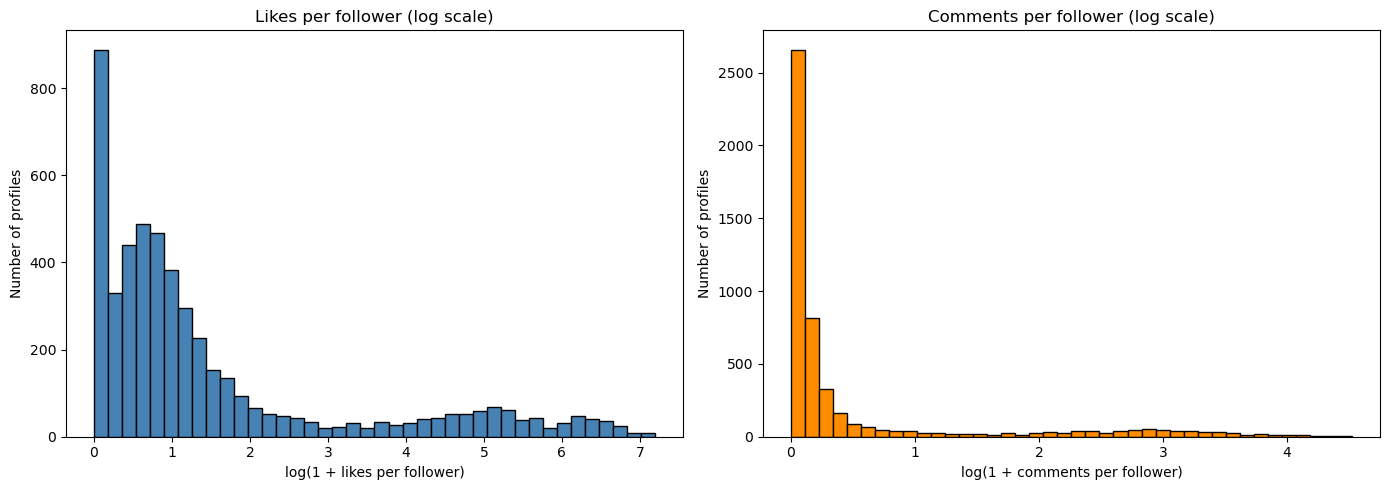

In [12]:
df_eda["likes_per_follower"] = (
    df_eda["likes_last_20_posts"] / (df_eda["followers_count"] + 1)
)
df_eda["comments_per_follower"] = (
    df_eda["comments_last_20_posts"] / (df_eda["followers_count"] + 1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(df_eda["likes_per_follower"]), bins=40, edgecolor="black", color="steelblue")
axes[0].set_xlabel("log(1 + likes per follower)")
axes[0].set_ylabel("Number of profiles")
axes[0].set_title("Likes per follower (log scale)")

axes[1].hist(np.log1p(df_eda["comments_per_follower"]), bins=40, edgecolor="black", color="darkorange")
axes[1].set_xlabel("log(1 + comments per follower)")
axes[1].set_ylabel("Number of profiles")
axes[1].set_title("Comments per follower (log scale)")

plt.tight_layout()
plt.show()

**Interpretation:**

- The engagement-per-follower distributions for both data sets range across multiple orders of magnitude (logarithmic scale).
- The **left tail**, which consists of profiles with little to no engagement even though they have followers, suggests profiles whose follower counts are artificially high compared to their actual engagement levels. This is precisely the type of profile flagged for moderation review.
- The **right tail** refers to accounts with significant engagement levels but few followers. They may appear odd but are not necessarily fraudulent accounts; rather, they are part of the "ambiguous creator" category.

### DM behavior: sent vs. replies

Spam accounts often blast many DMs but receive few replies (people don't engage with spam). A low reply rate combined with high send volume is a strong spam indicator.

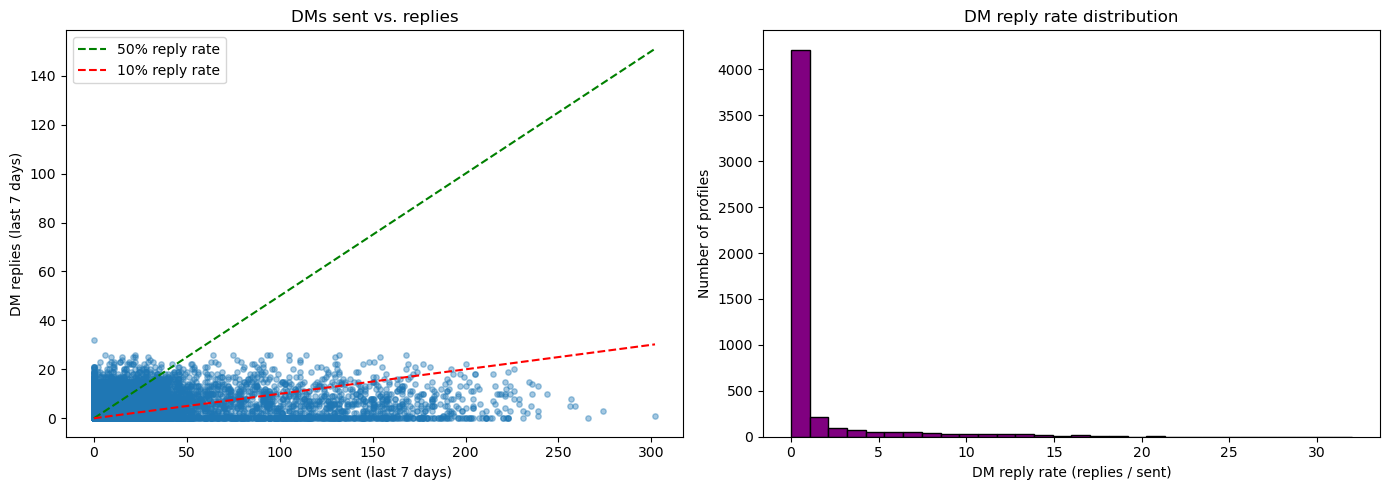

Profiles sending >50 DMs/week with <10% reply rate: 1161


In [13]:
df_eda["dm_reply_rate"] = (
    df_eda["dm_replies_last_7_days"] / (df_eda["dm_sent_last_7_days"] + 1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    df_eda["dm_sent_last_7_days"],
    df_eda["dm_replies_last_7_days"],
    alpha=0.4, s=15
)
max_sent = df_eda["dm_sent_last_7_days"].max()
axes[0].plot([0, max_sent], [0, max_sent * 0.5], color="green", linestyle="--", label="50% reply rate")
axes[0].plot([0, max_sent], [0, max_sent * 0.1], color="red", linestyle="--", label="10% reply rate")
axes[0].set_xlabel("DMs sent (last 7 days)")
axes[0].set_ylabel("DM replies (last 7 days)")
axes[0].set_title("DMs sent vs. replies")
axes[0].legend()

axes[1].hist(df_eda["dm_reply_rate"], bins=30, edgecolor="black", color="purple")
axes[1].set_xlabel("DM reply rate (replies / sent)")
axes[1].set_ylabel("Number of profiles")
axes[1].set_title("DM reply rate distribution")

plt.tight_layout()
plt.show()

high_send_low_reply = ((df_eda["dm_sent_last_7_days"] > 50) & (df_eda["dm_reply_rate"] < 0.1)).sum()
print(f"Profiles sending >50 DMs/week with <10% reply rate: {high_send_low_reply}")

**Interpretation:**

- The scatter plot indicates a group of profiles that have a **reply rate way below the 10% reply-rate line**, with many messages sent; a textbook definition of spam DM (a lot of outreach, very little response received).
- The histogram of reply rate is significantly right-skewed and has most values close to zero because high senders mostly receive a low reply rate.
- This emphasizes the necessity for a DM reply rate feature to be derived based on raw features to distinguish spam DMs from other types of messages.

# Feature Engineering

We engineer new features from the raw features to better capture behavioral patterns that distinguish fake profiles from real ones. Ratios and rates normalize behavior across accounts of different sizes and ages.

1. **follow_ratio** — Ratio of followers to following; fake accounts often follow many but have few followers.
2. **posts_per_day** — Total posts normalized by account age; flags abnormally high posting activity.
3. **recent_post_rate_30d** — Average posts per day over the last 30 days; captures recent posting bursts.
4. **repeated_caption_rate** — Share of recent posts with repeated captions; bots often recycle captions.
5. **night_post_rate** — Share of recent posts made at night; automated accounts often post at odd hours.
6. **likes_per_post_20** — Average likes across the last 20 posts; measures engagement quality.
7. **comments_per_post_20** — Average comments across the last 20 posts; another engagement signal.
8. **dm_reply_rate** — Ratio of DM replies to DMs sent; fake accounts usually send lot of DMs, but get reply rarely.
9. **username_digit_density** — Share of digits in the username; auto-generated usernames have many digits.
10. **links_per_post** — External links per post; spam accounts often share excessive links.

We add `+1` to denominators to avoid division-by-zero errors, then drop redundant raw columns to prevent multicollinearity.

In [14]:
df_fe = df.copy()

# 1. Follower/following ratio (handling division by zero)
df_fe["follow_ratio"] = df_fe["followers_count"] / (df_fe["following_count"] + 1)

# 2. Posting intensity
df_fe["posts_per_day"] = df_fe["posts_count"] / (df_fe["account_age_days"] + 1)

# 3. Recent activity rate
df_fe["recent_post_rate_30d"] = df_fe["posts_last_30_days"] / (30.0)

# 4. Caption repetition rate
df_fe["repeated_caption_rate"] = df_fe["repeated_captions"] / (df_fe["recent_posts_sampled"] + 1)

# 5. Night posting rate
df_fe["night_post_rate"] = df_fe["night_posts"] / (df_fe["recent_posts_sampled"] + 1)

# 6. Engagement per post (likes per recent post)
df_fe["likes_per_post_20"] = df_fe["likes_last_20_posts"] / 20.0

# 7. Engagement per post (comments per recent post)
df_fe["comments_per_post_20"] = df_fe["comments_last_20_posts"] / 20.0

# 8. DM pressure (sent vs replies)
df_fe["dm_reply_rate"] = df_fe["dm_replies_last_7_days"] / (df_fe["dm_sent_last_7_days"] + 1)

# 9. Username digit density
df_fe["username_digit_density"] = df_fe["username_digit_count"] / (df_fe["username_length"] + 1)

# 10. External links per post (rough proxy)
df_fe["links_per_post"] = df_fe["external_link_count"] / (df_fe["posts_count"] + 1)

# Drop redundant raw columns after feature engineering
df_fe = df_fe.drop(columns=[
    "posts_count",
    "likes_last_20_posts",
    "comments_last_20_posts",
    "username_digit_count",
    "username_length",
    "night_posts"
])

# Drop ID for modeling/clustering later, but keep separately
X_unlabeled = df_fe.drop(columns=[id_col])
profile_ids = df_fe[id_col].values

In [15]:
print(df_fe.isnull().sum())

profile_id                 0
account_age_days           0
bio_length                 0
profile_picture_quality    0
followers_count            0
following_count            0
posts_last_30_days         0
external_link_count        0
repeated_captions          0
recent_posts_sampled       0
avg_caption_length         0
dm_sent_last_7_days        0
dm_replies_last_7_days     0
follow_ratio               0
posts_per_day              0
recent_post_rate_30d       0
repeated_caption_rate      0
night_post_rate            0
likes_per_post_20          0
comments_per_post_20       0
dm_reply_rate              0
username_digit_density     0
links_per_post             0
dtype: int64


Sanity Check : After feature engineering also, the dataset has no null values.

## Train-Test Split

To avoid data leakage we will split the data before clustering.

In [16]:
df_train_unlabeled, df_holdout_unlabeled = train_test_split(
    df_fe,
    test_size=0.2,
    random_state=42
)

print(df_train_unlabeled.shape, df_holdout_unlabeled.shape)

(4000, 23) (1000, 23)


Now our dataset has 23 features. The training set has 4000 datapoints and the test (holdout) set has 1000 datapoints.

### Scaling before clustering

Since KMeans works by calculating the Euclidean distance, the features which have higher values (like `account_age_days` and `followers_count`) will dominate those with lower values (such as `night_post_rate` and `dm_reply_rate`). Hence we scale the training dataset.

In [17]:
# Identify numeric features
numeric_features = [c for c in df_train_unlabeled.columns if c != id_col]

scaler_cluster = StandardScaler()
X_train_scaled = scaler_cluster.fit_transform(df_train_unlabeled[numeric_features])

## KMeans Clustering

It is always better to use more clusters. Here, we will be taking number of clusters to be 20.

In [18]:
k = 20
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)

df_train_unlabeled["cluster"] = train_clusters

## Inspect Cluster-Level Summary

In [19]:
cluster_summary = df_train_unlabeled.groupby("cluster")[numeric_features].mean()
print(cluster_summary)

# Also looking at size of each cluster
print(df_train_unlabeled["cluster"].value_counts().sort_index())


         account_age_days  bio_length  profile_picture_quality  \
cluster                                                          
0              102.466019   27.844660                 0.406311   
1              929.901639   72.590164                 0.774915   
2                1.000000   28.313253                 0.396181   
3              105.007143   26.092857                 0.435843   
4              107.310345   30.201149                 0.406546   
5              930.750831   83.265781                 0.752797   
6             1020.875000   80.970395                 0.765569   
7               97.987179   31.474359                 0.428154   
8              999.800000   82.766667                 0.747211   
9              101.578571   28.535714                 0.425836   
10              98.218750   26.734375                 0.423289   
11             942.711191   92.252708                 0.758177   
12            1051.045161   80.380645                 0.760413   
13        

After fitting KMeans with k=20, we examine the **mean feature values within each cluster** along with each cluster's size. Cluster IDs are arbitrary on their own — only by inspecting within-cluster behavior (e.g., high posting rates, low engagement, high repeated-caption rates) can we tell which clusters look more fake vs true. This guides our SME sampling strategy and pseudo-label assignment in the next steps. Instead of randomly taking some labels from SME, we will now ask for the labels of the representative samples for each of the 20 clusters.

## Using SME

We will use SME to get labels for 15 samples per cluster (total 300 labels taken). We would use these to assign pseudo labels to our data.

In [21]:
from fake_profile_sme import SME
sme = SME()

samples_per_cluster = 15

sampled_rows = (
    df_train_unlabeled.groupby("cluster")
    .apply(lambda g: g.sample(min(len(g), samples_per_cluster), random_state=42))
    .reset_index(drop=True)
)

print(sampled_rows[["profile_id", "cluster"]].head())
len(sampled_rows)

  profile_id  cluster
0     P03495        0
1     P02422        0
2     P03754        0
3     P01230        0
4     P03993        0


C:\Users\madzf\AppData\Local\Temp\ipykernel_12392\910407950.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), samples_per_cluster), random_state=42))


300

In [22]:
sampled_rows["sme_label"] = sampled_rows[id_col].apply(lambda pid: sme.ask(pid))
sampled_rows["sme_label"].value_counts()

C:\Madhurima lenovo\Docs\MPS application\UMBC\Sem 2\Data 602\Final Project\fake_profile_sme.py:56: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.df[self.df["profile_id"] == profile_id]["fake_profile"])


sme_label
0    162
1    138
Name: count, dtype: int64

This indicates, from our SME sampling of 300 profiles, 162 profiles were labeled genuine and 138 profiles were labeled as fake. This confirms there is no accidental oversampling of one class. Hence the pseudo labels assigned on this basis would not be biased towards any single class.

In [23]:
cluster_label_stats = (
    sampled_rows.groupby("cluster")["sme_label"]
    .agg(["mean", "count", "sum"])
    .rename(columns={"mean": "fake_rate", "count": "n_sampled", "sum": "n_fake"})
)

print(cluster_label_stats.sort_values("fake_rate", ascending=False))

         fake_rate  n_sampled  n_fake
cluster                              
2         1.000000         15      15
13        1.000000         15      15
10        0.933333         15      14
7         0.933333         15      14
19        0.933333         15      14
4         0.866667         15      13
3         0.866667         15      13
16        0.866667         15      13
0         0.866667         15      13
9         0.666667         15      10
18        0.133333         15       2
6         0.066667         15       1
11        0.066667         15       1
5         0.000000         15       0
8         0.000000         15       0
1         0.000000         15       0
12        0.000000         15       0
14        0.000000         15       0
15        0.000000         15       0
17        0.000000         15       0


We can see that the SME sampling provided a lot of highly pure clusters with fake_rate close to 0 or 1. However there are some not so pure clusters as well. Accordingly, next we will assign pseudo labels based on some threshold.

## Pseudo Label Assignment

We will assign a threshold for cluster labeling : fake if fake_rate is at least 0.8, normal if fake_rate is less than or equal to 0.2, else ambiguous.

In [24]:
fake_threshold = 0.8
normal_threshold = 0.2

cluster_label_stats["cluster_label"] = np.where(
    cluster_label_stats["fake_rate"] >= fake_threshold, 1,
    np.where(cluster_label_stats["fake_rate"] <= normal_threshold, 0, -1)  # -1 = ambiguous
)

print(cluster_label_stats)


df_train_pseudo = df_train_unlabeled.merge(
    cluster_label_stats["cluster_label"],
    left_on="cluster",
    right_index=True,
    how="left"
)

# Keeping only confident clusters
df_train_pseudo = df_train_pseudo[df_train_pseudo["cluster_label"] != -1].copy()
df_train_pseudo = df_train_pseudo.rename(columns={"cluster_label": "pseudo_label"})

         fake_rate  n_sampled  n_fake  cluster_label
cluster                                             
0         0.866667         15      13              1
1         0.000000         15       0              0
2         1.000000         15      15              1
3         0.866667         15      13              1
4         0.866667         15      13              1
5         0.000000         15       0              0
6         0.066667         15       1              0
7         0.933333         15      14              1
8         0.000000         15       0              0
9         0.666667         15      10             -1
10        0.933333         15      14              1
11        0.066667         15       1              0
12        0.000000         15       0              0
13        1.000000         15      15              1
14        0.000000         15       0              0
15        0.000000         15       0              0
16        0.866667         15      13         

We can see that although most clusters are highly pure, one cluster falls into the ambiguous category based on the SME thresholds (0.2–0.8). This cluster is assigned a label of -1 to indicate uncertainty.

The presence of an ambiguous cluster is expected in semi‑supervised learning because not all the feature are cleanly separable. Ambiguous clusters represent mixed‑behavior profiles that share characteristics of both real and fake accounts. For example, a profile with unusually high engagement may reflect genuine follower interactions or alternately may even reflect artificially generated likes/comments. These borderline cases naturally group together and form an ambiguous cluster.

In this project, the ambiguous cluster was excluded from pseudo‑label training to avoid injecting noise into the model. However, it was included again during the final full‑dataset evaluation, since the goal at that stage is to compare the predictions against the true labels.

## Modeling

In [25]:
#setting up X and y in training set using the assigned pseudo labels

X_train = df_train_pseudo[numeric_features]
y_train = df_train_pseudo["pseudo_label"]

print(y_train.value_counts(normalize=True))

pseudo_label
0    0.654145
1    0.345855
Name: proportion, dtype: float64


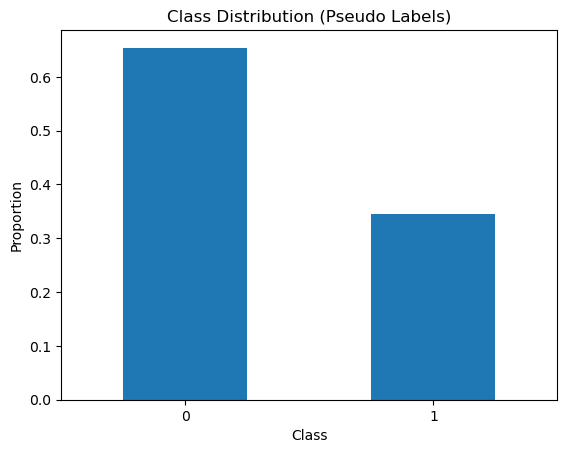

In [26]:
y_train.value_counts(normalize=True).sort_index().plot(kind='bar')

plt.title("Class Distribution (Pseudo Labels)")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

As we can see, the target variable in the training file is imbalanced, based on our pseudo labels.

## Preprocessing Pipeline

We only need scaling in the processing pipeline.

In [27]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("scaler", StandardScaler())]), 
     numeric_features)])

## Metric Selection: ROC-AUC

We use **ROC-AUC** as our chosen metric. Since the dataset is imbalanced, accuracy would not be an appropriate metric (we can see the imbalance in pseudo labels. Also, it was mentioned that the actual class distribution in labels file is also imbalanced). ROC-AUC measures how well the model seperates fake vs normal profiles, which aligns with our goal. It is threshold-independent and better for risk-based systems.

Next, we will fit multiple models, use cross-validation, tune the hyperparameters to improve roc-auc and make predictions on the previously created holdout set. At the end we will evaluate and compare each model performance.

## Logistic Regression

In [28]:
logreg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(penalty="l2",class_weight="balanced",max_iter=1000, solver="lbfgs"))
])

logreg_param_grid = {
    'model__C': [0.01, 0.1, 1, 10]
}

log_gscv = GridSearchCV(
    logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring='roc_auc',
    cv=5,
    refit=True
)

log_gscv_results = log_gscv.fit(X_train, y_train)

best_model_logreg = log_gscv_results.best_estimator_

print("Best C:", log_gscv_results.best_params_)

Best C: {'model__C': 1}


In Logistic Regression, we optimize the regularization strength using 5-fold GridSearchCV based on the **ROC-AUC** metric and the best estimator is refit automatically to the whole data set. 

Next, we calculate the predicted probabilities on the holdout (test) set and store the predictions for later comparison.

In [29]:
# Use the tuned and refit logistic regression model
X_holdout = df_holdout_unlabeled[numeric_features]

# Predict probabilities on the holdout set
holdout_proba_logreg = best_model_logreg.predict_proba(X_holdout)[:, 1]

# Store predictions
df_holdout_unlabeled["fake_proba_logreg"] = holdout_proba_logreg

## Random Forest

In [30]:
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [2, 3, 4, 5, 10, None]
}

rf_gscv = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=5,
    refit=True
)

rf_gscv_results = rf_gscv.fit(X_train, y_train)

best_model_rf = rf_gscv_results.best_estimator_

print("Best RF Params:", rf_gscv_results.best_params_)

Best RF Params: {'model__max_depth': None, 'model__n_estimators': 500}


For the Random Forest model, both the number of estimators and the maximum depth are adjusted using 5-fold GridSearchCV based on the ROC-AUC metric, and the optimum values are obtained.

Next, we calculate the predicted probabilities on the holdout (test) set and store the predictions for later comparison.

In [31]:
# Predict probabilities on the holdout set
holdout_proba_rf = best_model_rf.predict_proba(X_holdout)[:, 1]

# Store predictions
df_holdout_unlabeled["fake_proba_rf"] = holdout_proba_rf

## XGBoost

In [32]:
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_param_grid = {
    'model__n_estimators': [50, 55, 100, 200, 250, 280],
    'model__max_depth': [1, 2, 3, 6],
    'model__learning_rate': [0.01, 0.1, 0.4, 0.6, 0.8]
}

xgb_gscv = GridSearchCV(
    xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=5,
    refit=True
)

xgb_gscv_results = xgb_gscv.fit(X_train, y_train)

best_model_xgb = xgb_gscv_results.best_estimator_

print("Best XGB Params:", xgb_gscv_results.best_params_)

Best XGB Params: {'model__learning_rate': 0.4, 'model__max_depth': 3, 'model__n_estimators': 50}


In XGBoost model, we optimize our model based on three important parameters: n_estimators, max_depth, and learning_rate. GridSearchCV was used for tuning over 5-folds, with respect to ROC-AUC and the optimized values obtained.

Next, we calculate the predicted probabilities on the holdout (test) set and store the predictions for later comparison.

In [33]:
# Predict probabilities on the holdout set
holdout_proba_xgb = best_model_xgb.predict_proba(X_holdout)[:, 1]

# Store predictions
df_holdout_unlabeled["fake_proba_xgb"] = holdout_proba_xgb

Note: While hyperparameter tuning in RF and XGB, the best n_estimators value kept landing on the edge of the grid. We have tried expanding the grid multiple times and the result is same, it takes the highest one or lowest one in the grid. However, the performance doesn't improve significantly. Since this indicates that there has been a plateauing and performance is not improving significantly by increasing or decreasing n_estimators, we have stopped at an optimal point, when still the best parameter comes at the edge of the grid but the performance doesn't improve much by expanding the grid further.

# Comparing Models

## Pseudo Label Performance

In [34]:
# Logistic Regression
scores_log = cross_val_score(best_model_logreg, X_train, y_train,
                             cv=5, scoring="roc_auc")

# Random Forest
scores_rf = cross_val_score(best_model_rf, X_train, y_train,
                            cv=5, scoring="roc_auc")

# XGBoost
scores_xgb = cross_val_score(best_model_xgb, X_train, y_train,
                             cv=5, scoring="roc_auc")

print("Logistic CV ROC-AUC:", scores_log.mean())
print("RF CV ROC-AUC:", scores_rf.mean())
print("XGB CV ROC-AUC:", scores_xgb.mean())

Logistic CV ROC-AUC: 0.9999762672896502
RF CV ROC-AUC: 0.9999243519857602
XGB CV ROC-AUC: 0.9999480846961101


These scores indicate how well our models fit our pseudo labels. We can see all three models are performing really well. This shows we have been able to create strong pseudo labels.

## Performance on Unseen Holdout Set

In [35]:
# Load true labels
df_true = pd.read_csv("https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/fake_profiles_labels.csv")

# Merge with holdout predictions
df_eval_holdout = df_holdout_unlabeled.merge(df_true, on="profile_id", how="inner")


# True labels
y_true_holdout = df_eval_holdout["fake_profile"]

# Logistic Regression
auc_log_holdout = roc_auc_score(y_true_holdout, df_eval_holdout["fake_proba_logreg"])

# Random Forest
auc_rf_holdout = roc_auc_score(y_true_holdout, df_eval_holdout["fake_proba_rf"])

# XGBoost
auc_xgb_holdout = roc_auc_score(y_true_holdout, df_eval_holdout["fake_proba_xgb"])

print("Holdout ROC-AUC (Logistic):", auc_log_holdout)
print("Holdout ROC-AUC (RF):", auc_rf_holdout)
print("Holdout ROC-AUC (XGB):", auc_xgb_holdout)


Holdout ROC-AUC (Logistic): 0.9645324599230286
Holdout ROC-AUC (RF): 0.9619084352382278
Holdout ROC-AUC (XGB): 0.9580598657005198


As we can see, Logistic Regression model has the highest ROC-AUC among the three models (~ 96.45%). Hence **based on our chosen metric, we choose Logistic Regression as the final model**.

## Final Model

In [36]:
final_model = best_model_logreg

# Final Model Prediction on Full Dataset with True Labels

Now we will check the performance of our chosen Logistic Regression model on the full dataset with respect to the true labels.

In [37]:
# Predict on FULL dataset using the final chosen model (Logistic Regression)
X_full = df_fe[numeric_features]

# Predicted probabilities
full_proba_logreg = final_model.predict_proba(X_full)[:, 1]

# Store in df_fe
df_fe["fake_proba_bestmodel"] = full_proba_logreg
df_fe["fake_pred_bestmodel"] = (full_proba_logreg >= 0.5).astype(int)


Final ROC-AUC: 0.9636915830440639
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3198
           1       0.90      0.93      0.91      1802

    accuracy                           0.93      5000
   macro avg       0.93      0.93      0.93      5000
weighted avg       0.94      0.93      0.94      5000



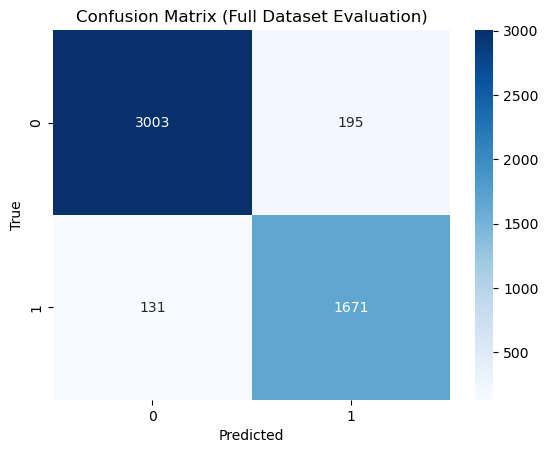

In [38]:
# Merge full data with predictions
df_eval_full = df_fe.merge(df_true, on="profile_id", how="inner")

y_true_full = df_eval_full["fake_profile"]
y_pred_full = df_eval_full["fake_pred_bestmodel"]
y_proba_full = df_eval_full["fake_proba_bestmodel"]

# Final evaluation
print("Final ROC-AUC:", roc_auc_score(y_true_full, y_proba_full))
print(classification_report(y_true_full, y_pred_full))

# Confusion matrix
cm = confusion_matrix(y_true_full, y_pred_full)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Full Dataset Evaluation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

The **final ROC-AUC is 96.37%** indicating our **model can correctly distinguish a fake profile from a normal profile around 96% of the time**. This is also consictent with the ROC-AUC for holdout set (96.45%) indicating that the model generalizes well.  

The classification report shows that the model **can correctly predict fake around 90% of the time** (precision), and it **catches 93% of all fake profiles** (recall).

The confusion matrix shows that the model misses only 131 fake profiles out of total 1802 ones.

Thus, overall it indicates that the final model generalizes well and quite accurately distinguishes between real and fake profiles.

# Comparison : Pseudo Labels vs True Labels

Finally, we will assign the pseudo labels to the data (including the train and holdout set this time) and merge with the full dataset to check the accuracy of our assigned pseudo labels with respect to the true labels.

In [39]:
# Recomputing cluster assignments for ALL 5000 rows
df_fe["cluster"] = kmeans.predict(df_fe[numeric_features])

C:\Users\madzf\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


In [40]:
#assigning pseudo label to all rows
cluster_to_label_dict = {}

for cluster_id, row in cluster_label_stats.iterrows():
    fr = row["fake_rate"]
    if fr >= 0.8:
        cluster_to_label_dict[cluster_id] = 1      # fake
    elif fr <= 0.2:
        cluster_to_label_dict[cluster_id] = 0      # real
    else:
        cluster_to_label_dict[cluster_id] = -1     # ambiguous

In [41]:
df_fe["pseudo_label"] = df_fe["cluster"].map(cluster_to_label_dict)

In [42]:
#merge with full data with true labels
df_full = df_fe.merge(df_true, on="profile_id", how="inner")

In [43]:
df_full[["profile_id", "pseudo_label", "fake_profile"]].sample(10)

,profile_id,pseudo_label,fake_profile
2153,P02154,0,0
4285,P04286,0,0
4216,P04217,0,1
4826,P04827,0,0
4359,P04360,0,0
4480,P04481,1,1
4,P00005,0,0
509,P00510,1,1
4412,P04413,0,0
1275,P01276,1,1


In [44]:
#checking accuracy of pseudo label
mask = df_full["pseudo_label"] != -1

pseudo = df_full.loc[mask, "pseudo_label"]
true = df_full.loc[mask, "fake_profile"]

pseudo_accuracy = (pseudo == true).mean()
print(f"Pseudo‑Label Accuracy: {pseudo_accuracy * 100:.2f}%")

Pseudo‑Label Accuracy: 89.58%


We can see our pseudo label assignment is around 89% accurate, indicating our semi-supervised learning method produced high‑quality pseudo‑labels and worked pretty well.

## Sanity Checks

Here we will compare the pseudo‑label distribution against the true label distribution to validate the pseudo label performance.

In [45]:
pseudo_dist = df_fe["fake_pred_bestmodel"].value_counts(normalize=True)
true_dist = df_true["fake_profile"].value_counts(normalize=True)

comparison = pd.DataFrame({
    "pseudo_label_dist": pseudo_dist,
    "true_label_dist": true_dist
})

print(comparison)

   pseudo_label_dist  true_label_dist
0             0.6268           0.6396
1             0.3732           0.3604


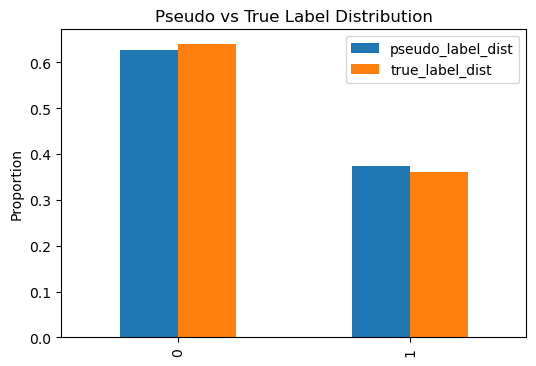

In [46]:
comparison.plot(kind="bar", figsize=(6,4), title="Pseudo vs True Label Distribution")
plt.ylabel("Proportion")
plt.show()

As we can see, the proportions are closely aligned, indicating that the semi‑supervised labeling pipeline captured the underlying class balance of the dataset pretty well. The little deviations are expected as the model was learning from pseudo‑labels rather than true labels.

# Conclusion

The solution was developed using a semi‑supervised learning pipeline. Since the true labels were not given, we first **created new behavioral features** (posting intensity, engagement ratios, username patterns, DM behavior, etc.) to capture meaningful signals of fake vs real profiles.

We then **applied KMeans clustering** to group similar profiles into 20 clusters and **used SME** sampling (15 samples per cluster) to manually inspect and **assign cluster‑level pseudo‑labels**. Cluster summary statistics (fake_rate, purity, and size distribution) were analyzed to validate that clusters were well‑separated. Ambiguous clusters were identified and excluded from training to avoid label noise.

**Three models (Logistic Regression, Random Forest, XGBoost) were trained** using cross‑validation on the pseudo‑labeled data. All models achieved high ROC‑AUC due to the strong separability of the engineered features. The **final model was selected as Logistic Regression, based on the ROC‑AUC of the holdout dataset using true labels.**

The final model was then **applied to the entire dataset, and predictions were evaluated against the true labels**. The pipeline achieved an **ROC‑AUC of 0.9637**, demonstrating strong discriminative power.

Finally, the assigned **pseudo labels were tested against the true labels** and the **accuracy came to be 89.58%, thus validating the effectiveness of the semi‑supervised approach.**

### Why It Worked

The pipeline worked well because the new created features captured meaningful behavioral differences between real and fake profiles, and the clustering step produced highly pure groups that aligned with SME judgments. Thus, the labels generated were high-quality, allowing the model to effectively learn a discriminative boundary from the dataset. The holdout set and full dataset ROC-AUC scores were close, showing that the model generalizes well, and the accuracy of the assigned labels with respect to the true labels shows that the semi-supervised approach used to generate labels was reliable.

### Saving the Final Model

In [47]:
import joblib

joblib.dump(final_model, 'logreg_fake_profile_model.pkl')
print("Model saved as 'logreg_fake_profile_model.pkl'")

Model saved as 'logreg_fake_profile_model.pkl'


In [48]:
joblib.dump(numeric_features, "numeric_features.pkl")

['numeric_features.pkl']